# Ejercicio de programación Regresión Lineal Multiple

Importamos librerias necesarias

In [75]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline
import pandas as pd

In [76]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## 2 Regresión lineal con multiples variables

Se implementa la regresión lineal multivariable para predecir la sensación térmica en grados Celsius. El archivo GlobalWeatherRepository.csv contiene un conjunto de datos meteorológicos globales con registros diarios de estaciones climáticas alrededor del mundo. Las variables de entrada son: temperatura real, humedad, velocidad del viento, presión atmosférica, visibilidad, nubosidad, índice UV, precipitación y ráfagas de viento. La variable objetivo es la sensación térmica en grados Celsius (feels_like_celsius).

<a id="section4"></a>
### 2.1 Normalización de caracteristicas

Al visualizar los datos se puede observar que las características tienen diferentes magnitudes; por ejemplo, la presión atmosférica puede tener valores alrededor de 1013 mb mientras que la precipitación puede ser cercana a 0. Por lo cual se debe transformar cada valor en una escala de valores similares, esto con el fin de que el descenso por el gradiente pueda converger más rápidamente y evitar que variables con magnitudes grandes dominen el aprendizaje del modelo.

In [77]:
# Cargar datos
# data = np.loadtxt(os.path.join('Datasets', 'ex1data2.txt'), delimiter=',')
data = pd.read_csv('/content/gdrive/MyDrive/IA26/DATA/GlobalWeatherRepository.csv', delimiter=',')
X = data[['temperature_celsius', 'wind_mph', 'pressure_mb',
          'precip_mm', 'humidity', 'cloud',
          'visibility_km', 'uv_index', 'gust_mph']].values
y = data['feels_like_celsius'].values
m = y.size
print("Número de datos:", m)
# imprimir algunos puntos de datos
print('{:>12s}{:>10s}{:>12s}{:>10s}{:>10s}{:>15s}'.format(
    'temp', 'wind', 'pressure', 'precip', 'humidity', 'feels_like'))
print('-'*65)
for i in range(10):
    print('{:12.2f}{:10.2f}{:12.2f}{:10.2f}{:10.2f}{:15.2f}'.format(
        X[i,0], X[i,1], X[i,2], X[i,3], X[i,4], y[i]))

Número de datos: 128443
        temp      wind    pressure    precip  humidity     feels_like
-----------------------------------------------------------------
       26.60      8.30     1012.00      0.00     24.00          25.30
       19.00      6.90     1012.00      0.10     94.00          19.00
       23.00      9.40     1011.00      0.00     29.00          24.60
        6.30      7.40     1007.00      0.30     61.00           3.80
       26.00      8.10     1011.00      0.00     89.00          28.70
       26.00      5.60     1013.00      0.02     84.00          28.20
        8.00      2.20     1014.00      0.00     93.00           7.10
       19.00      4.30     1017.00      0.13     40.00          19.00
        9.00      2.50     1027.00      0.00     87.00           9.10
       16.00     12.50     1013.00      0.00     63.00          16.00


In [78]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [79]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[  26.6    8.3 1012.  ...   10.     7.     9.5]
 [  19.     6.9 1012.  ...   10.     5.    11.4]
 [  23.     9.4 1011.  ...   10.     5.    13.9]
 ...
 [  21.1    2.2 1021.  ...    8.     2.9    2.4]
 [  19.5    5.4 1015.  ...   10.     9.5    6.2]
 [  16.8   13.  1019.  ...   10.     5.4   15.8]]
Media calculada: [2.14560887e+01 8.04884968e+00 1.01409132e+03 1.35670142e-01
 6.63309250e+01 4.00007163e+01 9.50750138e+00 3.39960294e+00
 1.13699836e+01]
Desviación estandar calculada: [ 9.67148703  7.31959375 10.52761028  0.56647067 24.01014714 34.09893342
  2.68420645  3.55816705  8.66861125]
[[ 0.53186354  0.03431206 -0.19865066 ...  0.18348016  1.01186847
  -0.21571893]
 [-0.25395151 -0.15695539 -0.19865066 ...  0.18348016  0.44978132
   0.00346266]
 [ 0.15963536  0.18459362 -0.29363898 ...  0.18348016  0.44978132
   0.29185949]
 ...
 [-0.0368184  -0.79906753  0.6562442  ... -0.56161902 -0.1404102
  -1.03476593]
 [-0.20225315 -0.36188479  0.08631429 ...  0.18348016  1.71447742
  -0.596

Despues de `featureNormalize` la funcion es provada, se añade el temino de interseccion a `X_norm`:

In [80]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [81]:
print(X)

[[ 1.          0.53186354  0.03431206 ...  0.18348016  1.01186847
  -0.21571893]
 [ 1.         -0.25395151 -0.15695539 ...  0.18348016  0.44978132
   0.00346266]
 [ 1.          0.15963536  0.18459362 ...  0.18348016  0.44978132
   0.29185949]
 ...
 [ 1.         -0.0368184  -0.79906753 ... -0.56161902 -0.1404102
  -1.03476593]
 [ 1.         -0.20225315 -0.36188479 ...  0.18348016  1.71447742
  -0.59640275]
 [ 1.         -0.48142428  0.6764242  ...  0.18348016  0.56219875
   0.51104108]]


<a id="section5"></a>
### 2.2 Descenso por el gradiente

X contiene 9 características meteorológicas más la columna de unos, resultando en 10 parámetros theta a optimizar. La función de hipótesis y la regla de actualización del descenso por el gradiente permanecen sin cambios.
Las funciones computeCostMulti y gradientDescentMulti están vectorizadas para soportar cualquier número de características. La función de costo está definida como:

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

donde:

$$ X = \begin{pmatrix}
- (x^{(1)})^T - \\
- (x^{(2)})^T - \\
\vdots \\
- (x^{(m)})^T - \\ \\
\end{pmatrix} \qquad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \\\end{bmatrix}$$



In [82]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [83]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


theta calculado por el descenso por el gradiente: [ 2.23331610e+01  1.18438215e+01 -1.59313477e-01  7.68680364e-02
  1.13971126e-01  1.09243056e+00  4.76370663e-02  2.16003734e-01
 -1.68037164e-01 -1.77733706e-02]
Sensación térmica predicha: 26.13 °C


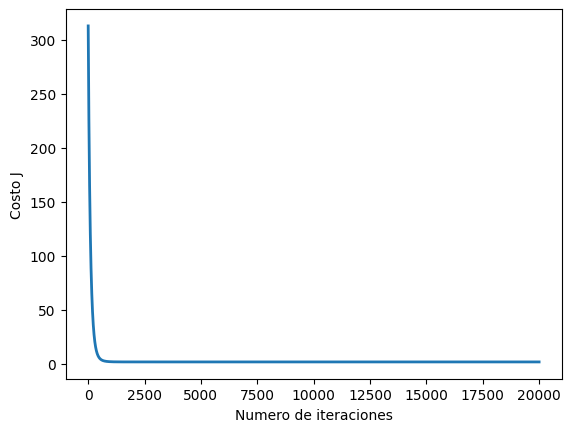

In [84]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.005 # alpha = 0.003
num_iters = 20000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Estimar el precio para una casa de 1650 sq-ft, con 3 dormitorios
# [sesgo, temp, viento, presión, precip, humedad, cloud, visibilidad, uv, ráfagas]
X_array = np.array([1, 25.0, 15.0, 1013.0, 0.0, 60.0, 30.0, 10.0, 5.0, 18.0], dtype=float)
X_array[1:] = (X_array[1:] - mu) / sigma
feels_like = np.dot(X_array, theta)
print('Sensación térmica predicha: {:.2f} °C'.format(feels_like))


In [85]:
# [sesgo, temp, humedad, viento, presión, visibilidad, cloud, uv_index, precip_mm, gust_mph]
X_array = np.array([1, 25.0, 60.0, 15.0, 1013.0, 10.0, 30.0, 5.0, 0.0, 18.0], dtype=float)
X_array[1:] = (X_array[1:] - mu) / sigma

In [86]:
feels_like = np.dot(X_array, theta)

print('Sensación térmica predicha (descenso por el gradiente): {:.2f} °C'.format(feels_like))

Sensación térmica predicha (descenso por el gradiente): 219.24 °C


<a id="section7"></a>
### 2.3 Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion exacta con un solo calculo: no hay “bucles de convergencia” como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$ para tener el termino de intersección($\theta_0$).

In [87]:
# Cargar datos
data = pd.read_csv('/content/gdrive/MyDrive/IA26/DATA/GlobalWeatherRepository.csv', delimiter=',')

X2 = data[['temperature_celsius', 'wind_mph', 'pressure_mb',
           'precip_mm', 'humidity', 'cloud',
           'visibility_km', 'uv_index', 'gust_mph']].values
y = data['feels_like_celsius'].values
m = y.size
print('Número de datos:', m)
X2 = np.concatenate([np.ones((m, 1)), X2], axis=1)

Número de datos: 128443


In [88]:
def normalEqn(X, y):

    theta2 = np.zeros(X.shape[1])

    theta2 = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta2

In [89]:
# Calcula los parametros con la ecuación de la normal
theta2 = normalEqn(X2, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta2)));

# Estimar el precio para una casa de superficie de 1650 sq-ft y tres dormitorios

# Predicción
# [sesgo, temp, humedad, viento, presión, visibilidad, cloud, uv_index, precip_mm, gust_mph]
X_array2 = [1, 25.0, 15.0, 1013.0, 0.0, 60.0, 30.0, 10.0, 5.0, 18.0]
feels_like2 = np.dot(X_array2, theta2)
print('Sensación térmica predicha (ecuación normal): {:.2f} °C'.format(feels_like2))

Theta calculado a partir de la ecuación de la normal: [-1.48513838e+01  1.22461465e+00 -2.16289332e-02  7.29911439e-03
  2.01242086e-01  4.55009805e-02  1.39647222e-03  8.04809523e-02
 -4.72427520e-02 -2.16595886e-03]
Sensación térmica predicha (ecuación normal): 26.14 °C
